# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en el Classroom como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).
2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.
3. Normaliza
4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada
5. Reserva un 20% de los datos del entrenamiento para validar.
6. Representa el objeto history
7. Evalua el modelo con los datos de test
8. Representa algunos de los paisajes donde el modelo comete errores
9. Crea una matriz de confusión con los errores del modelo

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import cv2
from skimage.io import imread

from tensorflow import keras
from sklearn.metrics import confusion_matrix

In [ ]:
# Definimos la lista de nombres de las categorías (clases) que queremos clasificar
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# Creamos un diccionario usando comprensión de diccionarios:
# 'enumerate' nos da el índice (i) y el nombre (class_name)
# El resultado mapea cada nombre a un número: {'buildings': 0, 'forest': 1, ...}
# Esto es necesario porque las redes neuronales solo entienden números, no texto.
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

# Mostramos el diccionario resultante para verificar que el mapeo es correcto
class_names_label


{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [7]:
PATH_train = r"C:\Users\Eneko\Desktop\EJERCICIO PAISAJES\seg_train"
PATH_test = r"C:\Users\Eneko\Desktop\EJERCICIO PAISAJES\seg_test"

In [8]:
IMAGE_SIZE = (32,32)
TRAIN_PATH = PATH_train
TEST_PATH = PATH_test

In [ ]:
def read_data(path, im_size):
    # Inicializamos listas vacías para guardar las imágenes (X) y las etiquetas (y)
    X = []
    y = []

    # Recorremos cada elemento (carpeta o archivo) dentro de la ruta principal
    for folder in os.listdir(path):
        # Creamos la ruta completa combinando la carpeta base con el nombre del elemento
        folder_path = os.path.join(path, folder)
        
        # 1. Seguridad: Si el elemento NO es una carpeta (ej. un archivo .h5 o .zip), 
        # lo saltamos para evitar errores de diccionario
        if not os.path.isdir(folder_path):
            continue
            
        # 2. Obtenemos el número (label) correspondiente al nombre de la carpeta
        # usando el diccionario 'class_names_label' que definimos antes
        label = class_names_label[folder]

        # Recorremos cada archivo de imagen dentro de la carpeta de la clase
        for file in os.listdir(folder_path):
            image_path = os.path.join(folder_path, file)
            try:
                # Leemos la imagen del disco
                image = imread(image_path)
                # Cambiamos el tamaño al definido en 'im_size' (ej. 150x150) para que todas sean iguales
                smallimage = cv2.resize(image, im_size)
                
                # Guardamos la imagen procesada y su etiqueta en nuestras listas
                X.append(smallimage)
                y.append(label)
            except:
                # Si una imagen está corrupta o no se puede leer, avisamos y seguimos con la siguiente
                print("Error en lectura imagen", image_path)

    # Convertimos las listas a arrays de NumPy (formato que requiere TensorFlow/Keras)
    return np.array(X), np.array(y)



In [ ]:
# Llamamos a la función para cargar y procesar las imágenes de entrenamiento
X_train, y_train = read_data(TRAIN_PATH, IMAGE_SIZE)

# Llamamos a la misma función para cargar las imágenes de prueba (test)
X_test, y_test = read_data(TEST_PATH, IMAGE_SIZE)

# Imprime las dimensiones de las imágenes de entrenamiento (ej: [num_fotos, ancho, alto, canales])
print(X_train.shape)

# Imprime las dimensiones de las imágenes de prueba
print(X_test.shape)

# Imprime la cantidad de etiquetas de entrenamiento (debe coincidir con el número de fotos en X_train)
print(y_train.shape)

# Imprime la cantidad de etiquetas de prueba (debe coincidir con X_test)
print(y_test.shape)


(14034, 32, 32, 3)
(3000, 32, 32, 3)
(14034,)
(3000,)


In [ ]:
# Convertimos el array de etiquetas 'y_train' a una Serie de Pandas para usar sus herramientas
# 'value_counts()' cuenta cuántas veces aparece cada número (etiqueta) en el dataset
# Esto te permite ver si tienes muchas más fotos de una clase que de otra
pd.Series(y_train).value_counts()


3    2512
2    2404
5    2382
4    2274
1    2271
0    2191
Name: count, dtype: int64

In [ ]:
# Cuenta cuántas imágenes hay de cada categoría dentro del conjunto de test
# Es vital para asegurar que la evaluación final sea justa y representativa 
# de todas las clases que el modelo debe aprender a distinguir.
pd.Series(y_test).value_counts()


2    553
3    525
4    510
5    501
1    474
0    437
Name: count, dtype: int64

In [ ]:
# Muestra los primeros 100 elementos del array de etiquetas de entrenamiento
# Sirve para verificar visualmente cómo están ordenados los datos 
# (por ejemplo, si vienen todos los '0' seguidos o si están mezclados)
y_train[:100]


array([3, 1, 5, 0, 5, 4, 4, 2, 0, 5, 4, 5, 4, 5, 1, 2, 3, 5, 1, 3, 5, 3,
       4, 0, 4, 5, 5, 2, 4, 2, 0, 0, 0, 2, 5, 3, 5, 5, 1, 0, 3, 3, 3, 4,
       2, 1, 1, 2, 1, 1, 1, 3, 1, 5, 2, 2, 1, 3, 4, 3, 5, 1, 0, 2, 1, 0,
       4, 0, 3, 0, 4, 4, 1, 4, 1, 3, 4, 3, 2, 3, 2, 0, 0, 2, 3, 5, 3, 0,
       3, 0, 4, 4, 4, 4, 3, 3, 2, 2, 1, 0])

In [ ]:
from sklearn.utils import shuffle

# Mezclamos las imágenes (X) y sus etiquetas (y) al mismo tiempo para que sigan emparejadas.
# Usamos 'random_state=29' para que la mezcla sea siempre la misma cada vez que corras el código
# (esto ayuda a que tus experimentos sean reproducibles).
X_train, y_train = shuffle(X_train, y_train, random_state=29)

# Hacemos lo mismo con los datos de prueba.
# Es especialmente importante si vas a usar un 'validation_split', para que el set de
# validación tenga ejemplos de todas las categorías y no solo de las últimas carpetas.
X_test, y_test = shuffle(X_test, y_test, random_state=29)


In [ ]:
# Mostramos las primeras 100 etiquetas después de haber barajado los datos.
# Si antes veías todo ceros o números seguidos, ahora deberías ver una 
# secuencia aleatoria (ej: 3, 0, 5, 2...), lo cual es ideal para el entrenamiento.
y_train[:100]


array([5, 4, 5, 4, 3, 3, 1, 2, 4, 3, 1, 1, 5, 1, 5, 3, 2, 3, 1, 2, 0, 5,
       3, 2, 2, 1, 0, 2, 2, 4, 2, 4, 5, 5, 1, 1, 3, 3, 4, 3, 1, 2, 2, 3,
       5, 5, 3, 3, 1, 0, 2, 1, 0, 1, 3, 1, 3, 4, 3, 1, 4, 4, 1, 3, 0, 2,
       3, 1, 5, 5, 3, 3, 5, 0, 1, 4, 3, 2, 1, 3, 2, 3, 0, 1, 3, 1, 0, 0,
       2, 3, 3, 3, 5, 2, 1, 4, 1, 5, 1, 5])

mountain


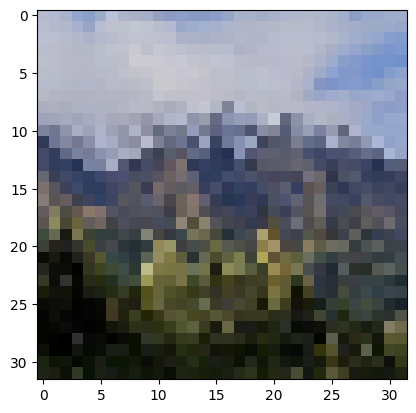

In [ ]:
# 1. Generamos un número aleatorio entre 0 y el total de imágenes que tenemos
# para elegir una foto al azar de nuestro set de entrenamiento
index = np.random.randint(X_train.shape[0])

# 2. Buscamos el nombre de la clase usando el número de etiqueta (y_train)
# como posición dentro de nuestra lista 'class_names' original
print(class_names[y_train[index]])

# 3. Mostramos la imagen que corresponde a ese índice para ver si coincide
# visualmente con lo que dice el texto de arriba
plt.imshow(X_train[index]);


In [ ]:
# Muestra la representación numérica de las imágenes en el set de entrenamiento.
# Lo que verás será una matriz gigante de números (de 0 a 255 si no has normalizado aún).
# Cada número representa la intensidad de color de un píxel en los canales R, G y B.
X_train


array([[[[133, 143, 168],
         [139, 146, 170],
         [142, 149, 170],
         ...,
         [212, 209, 205],
         [207, 204, 199],
         [209, 206, 201]],

        [[138, 147, 172],
         [138, 149, 175],
         [138, 150, 177],
         ...,
         [212, 208, 202],
         [225, 218, 210],
         [234, 225, 215]],

        [[136, 150, 178],
         [139, 153, 180],
         [143, 154, 180],
         ...,
         [231, 224, 218],
         [234, 225, 216],
         [232, 224, 215]],

        ...,

        [[103, 106, 113],
         [102, 105, 109],
         [ 92,  95,  97],
         ...,
         [ 16,  18,  15],
         [ 55,  58,  50],
         [ 29,  42,  17]],

        [[100, 101, 105],
         [ 95,  96,  96],
         [ 94,  96,  91],
         ...,
         [ 20,  28,  19],
         [ 30,  44,  30],
         [ 23,  35,  23]],

        [[ 94,  94,  94],
         [ 89,  89,  87],
         [ 94,  94,  91],
         ...,
         [ 34,  48,  33],
        

In [ ]:
# Accedemos al valor exacto del primer canal (R) del primer píxel 
# de la esquina superior izquierda de la primera imagen del dataset.
X_train[0][0][0][0]


np.uint8(133)

In [ ]:
# Muestra el valor mínimo encontrado en todo el dataset de imágenes.
# Si es 0 o cercano a 0, es lo normal (color negro o ausencia de intensidad).
print(X_train.min())

# Muestra el valor máximo encontrado en todo el dataset.
# Si sale 255, tus imágenes están SIN normalizar (píxeles puros).
# Si sale 1.0 (o cercano), tus imágenes ya están normalizadas y listas.
print(X_train.max())


0
255


In [ ]:
# Dividimos todos los valores de los píxeles por 255.
# Esto escala el rango original [0, 255] al rango [0, 1].
# Ayuda a que los gradientes no "exploten" y que el modelo converja mucho más rápido.
X_train = X_train / 255
X_test = X_test / 255


In [ ]:
# Comprobamos el nuevo valor mínimo después de la división.
# Debería seguir siendo 0.0 (o muy cercano si no había negros puros).
print(X_train.min())

# Comprobamos el nuevo valor máximo.
# ¡Ahora debería ser 1.0! Esto confirma que tus datos están en el rango 
# perfecto para que la red neuronal procese la información sin saturarse.
print(X_train.max())


0.0
1.0


In [ ]:
# Muestra las dimensiones del array de entrenamiento.
# El resultado suele ser (N, H, W, C):
# N: Número total de imágenes cargadas.
# H y W: Alto y ancho de las fotos (el 'im_size' que definiste).
# C: Canales de color (3 para imágenes RGB a color, 1 para blanco y negro).
X_train.shape


(14034, 32, 32, 3)

In [ ]:
model = keras.Sequential([
    # 1. Primera capa convolucional: Extrae 64 características básicas (bordes, texturas) 
    # con filtros de 3x3. El input_shape debe coincidir con tus imágenes de 32x32 píxeles.
    keras.layers.Conv2D(64, (3,3), input_shape=(32,32,3)),
    
    # 2. MaxPooling: Reduce el tamaño de la imagen a la mitad (16x16) para que el modelo 
    # sea más rápido y se quede con la información más importante.
    keras.layers.MaxPooling2D(2,2),
    
    # 3. Segunda convolución: Busca patrones más complejos (formas) usando 32 filtros.
    keras.layers.Conv2D(32, (3,3)),
    
    # 4. Segundo MaxPooling: Vuelve a reducir el tamaño (ahora a 8x8 aproximadamente).
    keras.layers.MaxPooling2D(2,2),
    
    # 5. Flatten: Estira la matriz 2D de la imagen en un vector de una sola columna 
    # para poder conectarla a las capas densas (las "neuronas" clásicas).
    keras.layers.Flatten(),
    
    # 6. Capa Densa (Densa 64): Procesa las características extraídas para aprender a clasificar.
    keras.layers.Dense(64, activation="relu"),
    
    # 7. Capa Densa (Densa 16): Una capa intermedia para refinar aún más la decisión.
    keras.layers.Dense(16, activation="relu"),
    
    # 8. Capa de Salida: Tiene 6 neuronas (una por cada clase: bosque, mar, etc.).
    # 'softmax' convierte los resultados en probabilidades que suman 100%.
    keras.layers.Dense(6, activation="softmax")
])


c:\Users\Eneko\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,190 (371.84 KB)

 Trainable params: 95,190 (371.84 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Configuramos cómo va a aprender el modelo
model.compile(
    # 'sparse_categorical_crossentropy' es la función de pérdida ideal cuando 
    # tus etiquetas (y_train) son números enteros (0, 1, 2, 3, 4, 5).
    loss="sparse_categorical_crossentropy", 
    
    # El optimizador por defecto es 'rmsprop', pero si ves que no mejora, 
    # podrías probar con optimizer='adam', que suele ser el estándar hoy en día.
    
    # 'accuracy' (precisión) nos dirá qué porcentaje de imágenes está 
    # clasificando correctamente durante el entrenamiento.
    metrics=['accuracy']
)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Configuramos el callback de EarlyStopping
early_stop = EarlyStopping(
    # Monitorizamos la pérdida de validación: si deja de bajar, es señal de sobreentrenamiento
    monitor='val_loss', 
    # Le damos 10 épocas de margen. Si en 10 intentos no logra mejorar el récord anterior, se detiene
    patience=10,         
    # Al terminar, el modelo no se queda con el último estado (que suele ser peor),
    # sino que vuelve automáticamente a los pesos que dieron el mejor resultado histórico
    restore_best_weights=True 
)

# 2. Lanzamos el proceso de entrenamiento
history = model.fit(
    X_train,             # Tus imágenes de entrenamiento (ya mezcladas y normalizadas)
    y_train,             # Tus etiquetas numéricas
    batch_size=128,      # Procesa 128 imágenes antes de actualizar los pesos de la red
    epochs=100,          # Máximo de vueltas completas al dataset
    validation_split=0.2,# Separa un 20% de los datos para evaluar cómo va el modelo sin que los "vea" para aprender
    callbacks=[early_stop] # Activamos nuestro freno automático
)



Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8358 - loss: 0.4594 - val_accuracy: 0.7061 - val_loss: 0.8753
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8517 - loss: 0.4182 - val_accuracy: 0.7061 - val_loss: 0.8844
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8605 - loss: 0.3903 - val_accuracy: 0.7253 - val_loss: 0.8924
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8741 - loss: 0.3593 - val_accuracy: 0.7036 - val_loss: 0.9772
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8830 - loss: 0.3306 - val_accuracy: 0.6762 - val_loss: 1.0436
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8974 - loss: 0.2976 - val_accuracy: 0.7243 - val_loss: 0.9295
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9025 - loss: 0.2826 - val_accuracy: 0.7175 - val_loss: 0.9641
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9132 - loss: 0.2487 - val_accuracy: 0.

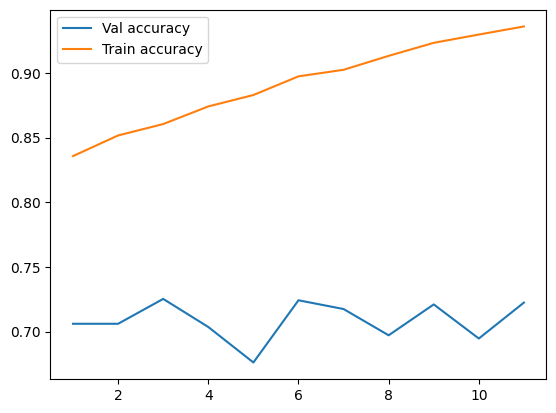

In [ ]:
# 1. Convertimos el diccionario de historia (history.history) en un DataFrame de Pandas
# Contiene la precisión (accuracy) y la pérdida (loss) de cada época
df_hist = pd.DataFrame(history.history)

# 2. Ajustamos el índice del DataFrame:
# Por defecto empieza en 0, pero lo cambiamos para que empiece en 1 hasta el total de épocas reales
df_hist.index = np.arange(1, len(df_hist) + 1)

# 3. Graficamos la precisión del set de validación (el 20% que el modelo no usó para aprender)
plt.plot(df_hist['val_accuracy'], label="Val accuracy")

# 4. Graficamos la precisión del set de entrenamiento (lo que el modelo ya conoce)
plt.plot(df_hist['accuracy'], label="Train accuracy")

# 5. Añadimos la leyenda para identificar cada línea y mostramos el dibujo final
plt.legend()
plt.show()



In [ ]:
# Evaluamos el modelo final utilizando el conjunto de datos de prueba (test)
# 'evaluate' devuelve una lista con los valores finales: [pérdida, precisión]
results = model.evaluate(X_test, y_test)

# Por ejemplo, si quieres ver solo la precisión final de forma amigable:
# print(f"Precisión final en Test: {results[1]*100:.2f}%")


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6983 - loss: 0.8844


In [ ]:
# 1. El modelo analiza las imágenes de prueba y genera sus "apuestas".
# 'y_pred' no contiene nombres de clases, sino una lista de probabilidades
# para cada una de las 6 categorías (ej: [0.1, 0.8, 0.05, ...])
y_pred = model.predict(X_test)

# 2. Redondeamos a 2 decimales para que sea mucho más fácil de leer.
# Así verás rápidamente cuál es la clase con la probabilidad más alta.
# Ejemplo: 0.95 significa que el modelo está un 95% seguro de esa clase.
y_pred.round(2)


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


array([[0.02, 0.  , 0.46, 0.5 , 0.02, 0.  ],
       [0.01, 0.  , 0.84, 0.13, 0.01, 0.01],
       [0.04, 0.  , 0.24, 0.2 , 0.52, 0.01],
       ...,
       [0.  , 0.02, 0.03, 0.95, 0.  , 0.  ],
       [0.  , 0.  , 0.01, 0.98, 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  ]],
      shape=(3000, 6), dtype=float32)

In [45]:
IMAGE_SIZE = (64,64)

In [ ]:
# 1. Cargamos las imágenes y etiquetas de entrenamiento desde la ruta definida
X_train, y_train = read_data(TRAIN_PATH, IMAGE_SIZE)

# 2. Cargamos las imágenes y etiquetas de prueba (el examen final del modelo)
X_test, y_test = read_data(TEST_PATH, IMAGE_SIZE)

# 3. Mostramos las dimensiones de las imágenes de entrenamiento (Cantidad, Alto, Ancho, Canales de color)
# Si IMAGE_SIZE era (32, 32), verás algo como (N, 32, 32, 3)
print(X_train.shape)

# 4. Dimensiones de las imágenes de test
print(X_test.shape)

# 5. Cantidad de etiquetas de entrenamiento (debe ser igual a la primera cifra de X_train.shape)
print(y_train.shape)

# 6. Cantidad de etiquetas de test (debe ser igual a la primera cifra de X_test.shape)
print(y_test.shape)


(14034, 64, 64, 3)
(3000, 64, 64, 3)
(14034,)
(3000,)


In [ ]:
# 1. Mezclamos (shuffle) aleatoriamente las imágenes y sus etiquetas.
# Usamos 'random_state=42' (un clásico) para que la mezcla sea siempre igual 
# si repetimos el experimento, pero los datos queden bien desordenados.
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

# 2. Normalización: Dividimos cada píxel entre 255.
# Pasamos de un rango [0, 255] a un rango decimal [0.0, 1.0].
# Esto evita que los valores grandes saturen las funciones de activación de la red.
X_train = X_train / 255
X_test = X_test / 255


In [ ]:
# Muestra las dimensiones de la matriz de entrenamiento: (número de filas, número de columnas)
print(X_train.shape) 


(14034, 64, 64, 3)


In [ ]:
model_2 = keras.Sequential([
    # Capa convolucional: 64 filtros de 3x3 para detectar patrones simples (bordes, texturas)
    # input_shape=(64,64,3) indica imágenes de 64x64 píxeles en color (RGB)
    keras.layers.Conv2D(64, (3,3), input_shape=(64,64,3)),
    
    # Reducción de dimensionalidad: se queda con el valor máximo en ventanas de 2x2
    keras.layers.MaxPooling2D(2,2),
    
    # Segunda convolución: sube a 128 filtros para detectar patrones más complejos
    keras.layers.Conv2D(128, (3,3)),
    keras.layers.MaxPooling2D(2,2),
    
    # Tercera convolución: vuelve a 64 filtros para refinar la extracción de características
    keras.layers.Conv2D(64, (3,3)),
    keras.layers.MaxPooling2D(2,2),
    
    # Aplana los mapas de características 3D a un vector 1D para entrar a la red densa
    keras.layers.Flatten(),
    
    # Capas ocultas densas con activación ReLU para aprender relaciones no lineales
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    
    # Capa de salida: 6 neuronas (una por clase) con Softmax para dar probabilidades
    keras.layers.Dense(6, activation="softmax")
])

# Configuración del aprendizaje: optimizador Adam y pérdida para etiquetas enteras (sparse)
model_2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])

history_2 = model_2.fit(
    X_train,
    y_train,
    batch_size=64,          # Procesa 64 imágenes antes de actualizar pesos
    epochs=30,              # Máximo de 30 pasadas completas por los datos
    validation_split=0.2,   # Usa el 20% de los datos para validar y evitar sobreajuste
    # EarlyStopping: detiene el entrenamiento si el modelo no mejora tras 10 épocas
    callbacks=[keras.callbacks.EarlyStopping(patience=10)]
)


c:\Users\Eneko\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 152ms/step - accuracy: 0.5584 - loss: 1.1206 - val_accuracy: 0.6641 - val_loss: 0.9103
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 158ms/step - accuracy: 0.6934 - loss: 0.8229 - val_accuracy: 0.7111 - val_loss: 0.7795
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 158ms/step - accuracy: 0.7353 - loss: 0.7234 - val_accuracy: 0.7492 - val_loss: 0.7102
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.7742 - loss: 0.6173 - val_accuracy: 0.7570 - val_loss: 0.6578
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.8120 - loss: 0.5291 - val_accuracy: 0.7659 - val_loss: 0.6831
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 25s 143ms/step - accuracy: 0.8254 - loss: 0.4690 - val_accuracy: 0.7724 - val_loss: 0.6442
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 25s 143ms/step - accuracy: 0.8586 - loss: 0.3910 - val_accuracy: 0.7624 - val_loss: 0.7366
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.8898 - loss: 0

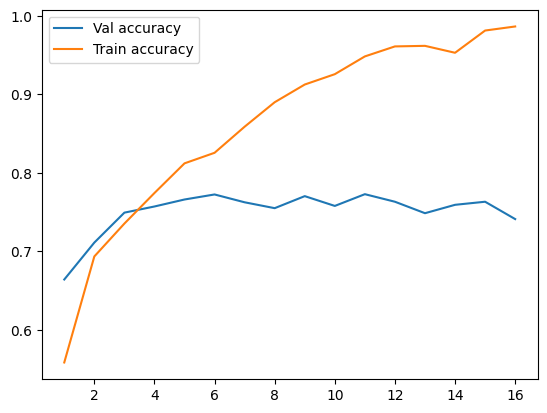

In [ ]:
# Convierte el diccionario de métricas (loss, accuracy, etc.) en un DataFrame de Pandas
df_hist = pd.DataFrame(history_2.history)

# Ajusta el índice para que empiece en 1 en lugar de 0 (ej: Época 1, Época 2...)
# np.arange genera una secuencia desde 1 hasta el total de épocas ejecutadas
df_hist.index = np.arange(1, len(df_hist) + 1)

# Crea el gráfico de líneas para la precisión de validación (datos no vistos)
plt.plot(df_hist['val_accuracy'], label="Val accuracy")

# Crea el gráfico de líneas para la precisión de entrenamiento (datos conocidos)
plt.plot(df_hist['accuracy'], label="Train accuracy")

# Muestra el cuadro de leyenda para identificar qué línea es cada una
plt.legend()

# Despliega la gráfica final en pantalla
plt.show()



In [ ]:
# Evalúa el rendimiento del modelo final utilizando el conjunto de datos de prueba (datos que el modelo nunca ha visto)
# Retorna una lista: [pérdida (loss), precisión (accuracy)]
results = model_2.evaluate(X_test, y_test)


94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7240 - loss: 1.4947


In [ ]:
# El modelo genera las predicciones para el set de prueba.
# Retorna una matriz de probabilidades (una por cada una de las 6 clases) para cada imagen.
y_pred = model_2.predict(X_test)

# Redondea las probabilidades a 2 decimales para que sea mucho más fácil de leer.
# Ejemplo: transforma 0.0000234 en 0.0 y 0.9876 en 0.99.
y_pred.round(2)


94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


array([[0.  , 0.  , 0.05, 0.95, 0.  , 0.  ],
       [0.  , 0.  , 0.99, 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.15, 0.2 , 0.65, 0.  ],
       ...,
       [0.  , 0.  , 0.02, 0.98, 0.  , 0.  ],
       [0.  , 0.  , 0.48, 0.16, 0.37, 0.  ],
       [0.  , 0.82, 0.  , 0.  , 0.  , 0.18]],
      shape=(3000, 6), dtype=float32)

mountain


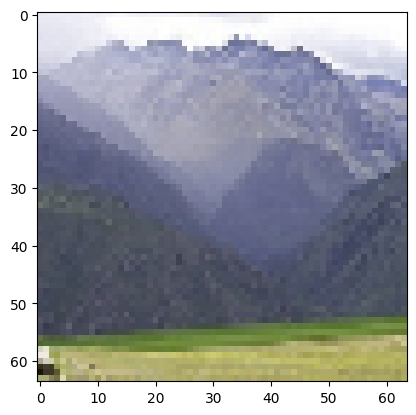

In [ ]:
# Muestra el nombre de la categoría real de la primera imagen del set de prueba
# y_test[0] obtiene el índice y class_names lo traduce a texto (ej: "Perro", "Gato")
print(class_names[y_test[0]])

# Muestra la imagen física correspondiente al índice 0 para verificarla visualmente
plt.imshow(X_test[0])

# Es necesario llamar a show() para que la imagen se despliegue en pantalla
plt.show()


In [ ]:
# Convierte las probabilidades en una sola clase (el índice con el valor más alto)
# np.argmax busca el valor máximo en cada fila (axis=1) de las predicciones
pred_labels = np.argmax(y_pred, axis=1)

# Imprime los índices numéricos predichos (ej: [0, 5, 2...])
print(pred_labels)

# Traduce los números a nombres de texto usando la lista 'class_names'
# Crea una nueva lista mediante una comprensión de lista (list comprehension)
pred_names = [class_names[pred] for pred in pred_labels]

# Imprime los nombres finales de las categorías predichas (ej: ['Coche', 'Edificio'...])
print(pred_names)


[3 2 4 ... 3 2 1]
['mountain', 'glacier', 'sea', 'street', 'street', 'glacier', 'glacier', 'sea', 'buildings', 'street', 'sea', 'street', 'forest', 'mountain', 'street', 'forest', 'glacier', 'forest', 'street', 'street', 'mountain', 'mountain', 'glacier', 'glacier', 'glacier', 'sea', 'mountain', 'glacier', 'buildings', 'mountain', 'glacier', 'glacier', 'forest', 'street', 'buildings', 'buildings', 'glacier', 'mountain', 'street', 'street', 'mountain', 'buildings', 'buildings', 'forest', 'glacier', 'mountain', 'sea', 'buildings', 'buildings', 'glacier', 'mountain', 'sea', 'buildings', 'mountain', 'buildings', 'street', 'sea', 'buildings', 'buildings', 'mountain', 'forest', 'forest', 'forest', 'street', 'street', 'glacier', 'sea', 'glacier', 'mountain', 'forest', 'mountain', 'street', 'street', 'mountain', 'glacier', 'forest', 'sea', 'street', 'sea', 'mountain', 'mountain', 'mountain', 'forest', 'glacier', 'mountain', 'buildings', 'street', 'glacier', 'sea', 'forest', 'buildings', 'glaci

<Axes: >

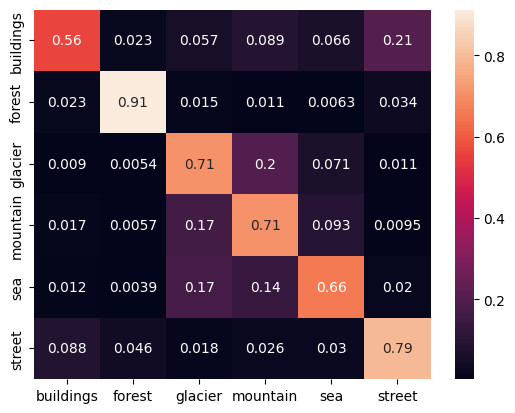

In [ ]:
# Calcula la matriz de confusión comparando etiquetas reales vs predicciones.
# normalize='true' muestra porcentajes (0 a 1) en lugar de conteos absolutos;
# esto ayuda a ver el rendimiento por clase independientemente de cuántas imágenes tenga cada una.
c_mat = confusion_matrix(y_test, pred_labels, normalize='true')

# Crea un mapa de calor (heatmap) para visualizar la matriz de forma gráfica.
# annot=True: escribe el porcentaje de acierto dentro de cada cuadro.
# xticklabels/yticklabels: asigna los nombres de las categorías a los ejes para saber qué clase es cada fila/columna.
sns.heatmap(c_mat, annot=True, xticklabels=class_names, yticklabels=class_names)


In [ ]:
# Importa la función para generar un reporte estadístico detallado de la clasificación
from sklearn.metrics import classification_report

# Genera e imprime métricas clave (precision, recall, f1-score) comparando 
# las etiquetas reales (y_test) con las predicciones del modelo (pred_labels)
print(classification_report(y_test, pred_labels))


              precision    recall  f1-score   support

           0       0.76      0.56      0.65       437
           1       0.91      0.91      0.91       474
           2       0.65      0.71      0.68       553
           3       0.61      0.71      0.66       525
           4       0.71      0.66      0.69       510
           5       0.76      0.79      0.77       501

    accuracy                           0.72      3000
   macro avg       0.73      0.72      0.72      3000
weighted avg       0.73      0.72      0.72      3000



In [ ]:
model_3 = keras.Sequential([
    # Primera capa convolucional con 32 filtros (más ligera que el modelo anterior)
    keras.layers.Conv2D(32, (3,3), input_shape=(64,64,3)),
    keras.layers.MaxPooling2D(2,2),
    
    # Dropout: Apaga aleatoriamente el 25% de las neuronas para evitar que el modelo memorice (overfitting)
    keras.layers.Dropout(0.25),
    
    # Segunda capa convolucional reducida a 16 filtros para simplificar el aprendizaje
    keras.layers.Conv2D(16, (3,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(0.25),
    
    keras.layers.Flatten(),
    
    # Capas densas más pequeñas (32 y 16 neuronas) para un modelo más ligero y rápido
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dense(16,activation="relu"),
    
    # Salida con 6 neuronas y Softmax para clasificación multiclase
    keras.layers.Dense(6, activation="softmax")
])

# Compilación con el optimizador Adam y pérdida de entropía cruzada para etiquetas enteras
model_3.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])

history_3 = model_3.fit(
    X_train,
    y_train,
    batch_size=128,          # Lotes más grandes (procesa más imágenes antes de actualizar pesos)
    epochs=30,
    validation_split=0.2,
    # EarlyStopping con paciencia reducida a 5 épocas: se detiene más rápido si no hay mejora
    callbacks=[keras.callbacks.EarlyStopping(patience=5)]
)


c:\Users\Eneko\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.4278 - loss: 1.3941 - val_accuracy: 0.5522 - val_loss: 1.1527
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.5738 - loss: 1.0985 - val_accuracy: 0.5639 - val_loss: 1.1280
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.6201 - loss: 1.0008 - val_accuracy: 0.6259 - val_loss: 0.9896
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.6502 - loss: 0.9258 - val_accuracy: 0.5761 - val_loss: 1.1286
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.6722 - loss: 0.8677 - val_accuracy: 0.6719 - val_loss: 0.8859
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.6972 - loss: 0.8113 - val_accuracy: 0.6740 - val_loss: 0.8865
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.7208 - loss: 0.7470 - val_accuracy: 0.6494 - val_loss: 0.9624
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.7405 - loss: 0.6986 - val_accuracy: 0.6990 - v

In [ ]:
# Evalúa el rendimiento del tercer modelo (el que incluye Dropout) con el set de prueba.
# Calcula la pérdida y la precisión final sobre datos que el modelo nunca ha visto durante el entrenamiento.
results = model_3.evaluate(X_test, y_test)


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7440 - loss: 0.8873
